# Optimal control investigations

In [33]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as colormaps
import pickle
import numpy as np
import os
import sys

import neurolib.dashboard.data as data
import neurolib.dashboard.functions as functions
import neurolib.dashboard.layout as layout
from neurolib.models.aln import ALNModel

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

### Mapping of bistable regime

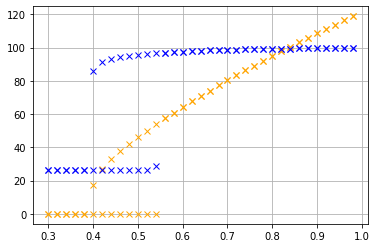

In [2]:
aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

readpath = '.' + os.sep + 'data' + os.sep + '00000'

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

aln.params.ext_inh_current = 0.5 * 5.

for i in np.arange(0.3,1,0.02):    
    aln.params.ext_exc_current = i * 5.

    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    up_ = np.zeros((2))
    up_[0] = aln.rates_exc[0,-1] 
    up_[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    down_ = np.zeros((2))
    down_[0] = aln.rates_exc[0,-1] 
    down_[1] = aln.rates_inh[0,-1]
    
    plt.plot(i, up_[0], "x", color="orange")
    plt.plot(i, up_[1], "x", color="blue")
    plt.plot(i, down_[0], "x", color="orange")
    plt.plot(i, down_[1], "x", color="blue")
    
plt.show()

- no need to go "beyond" boundary horizontally, as rate is above target rate

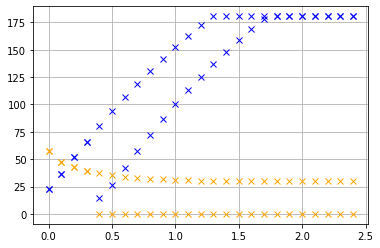

In [3]:
aln.params.ext_exc_current = 0.45 * 5.

for i in np.arange(0.,2.5,0.1):    
    aln.params.ext_inh_current = i * 5.

    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    up_ = np.zeros((2))
    up_[0] = aln.rates_exc[0,-1] 
    up_[1] = aln.rates_inh[0,-1]
    
    control0 = functions.step_control(aln, maxI_ = -3.)
    aln.run(control=control0)

    down_ = np.zeros((2))
    down_[0] = aln.rates_exc[0,-1] 
    down_[1] = aln.rates_inh[0,-1]
    
    plt.plot(i, up_[0], "x", color="orange")
    plt.plot(i, up_[1], "x", color="blue")
    plt.plot(i, down_[0], "x", color="orange")
    plt.plot(i, down_[1], "x", color="blue")
    
plt.show()

- rate "beyond" boundary is increasing when going downwards vertically, no need to go beyond boundary

In [4]:
aln = ALNModel()
data.set_parameters(aln)
dt = aln.params.dt
up_rates = np.zeros((len(ext_exc), 2))
down_rates = np.zeros((len(ext_exc), 2))
diff_rates = np.zeros((len(ext_exc), 2))

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))
dist_attractor_rate = np.zeros((len(ext_exc), 2))
dist_attractor_rate_perc = np.zeros((len(ext_exc), 1))

for i in range(len(ext_exc)):
    print(i, len(ext_exc))
    dist_up_regime[i,0] = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    dist_up_regime[i,1] = data.dist_low(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    dist_down_regime[i] = data.dist_left(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    
    aln.params.ext_exc_current = ext_exc[i] * 5.
    aln.params.ext_inh_current = ext_inh[i] * 5.

    aln.params.duration = 3000.
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = 3.)
    aln.run(control=control0)

    up_ = np.zeros((2))
    up_[0] = aln.rates_exc[0,-1] 
    up_[1] = aln.rates_inh[0,-1]
    
    high_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            high_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            high_state_vars[j] = aln.state[state_vars[j]][0,-1]

    control0 = functions.step_control(aln, maxI_ = - 3.)
    aln.run(control=control0)

    down_ = np.zeros((2))
    down_[0] = aln.rates_exc[0,-1] 
    down_[1] = aln.rates_inh[0,-1]
    
    up_rates[i,:] = up_
    down_rates[i,:] = down_
    diff_rates[i,:] = up_ - down_
    
    low_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            low_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            low_state_vars[j] = aln.state[state_vars[j]][0,-1]
            
    init_state_vars = low_state_vars
                
    aln.params.duration = 300.
    
    data.setinit(aln, init_state_vars)
    attr = True
    while attr:
        aln.params['rates_exc_init'] += 1.
        aln.run(control=aln.getZeroControl())
        if np.abs(aln.rates_exc[0,-1] - down_rates[i,0]) > 1.:
            #print("No longer in low attractor for init exc rate = ", aln.params['rates_exc_init'])
            dist_attractor_rate[i,0] = aln.params['rates_exc_init'] - init_state_vars[0]
            #plt.plot(np.arange(0, aln.params.duration + dt, dt), aln.rates_exc[0,:], color="red")
            attr = False
    
    data.setinit(aln, init_state_vars)
    attr = True
    while attr:
        aln.params['rates_inh_init'] += 1.
        aln.run(control=aln.getZeroControl())
        if np.abs(aln.rates_inh[0,-1] - down_rates[i,1]) > 1.:
            #print("No longer in low attractor for init inh rate = ", aln.params['rates_inh_init'])
            dist_attractor_rate[i,1] = aln.params['rates_inh_init'] - init_state_vars[1]
            #plt.plot(np.arange(0, aln.params.duration + dt, dt), aln.rates_inh[0,:], color="blue")
            #plt.show()
            attr = False
            
    data.setinit(aln, init_state_vars)
    attr = True
    aln.params['rates_exc_init'][:] = down_[0]
    aln.params['rates_inh_init'][:] = down_[1]
    percent = 0.0
    init_state_vars = low_state_vars
    while attr:
        percent += 0.01
        #print(percent)
        init_state_vars = low_state_vars + percent * (high_state_vars - low_state_vars)
        data.setinit(aln, init_state_vars)
        aln.params['rates_exc_init'] += percent * (up_[0] - down_[0])
        aln.params['rates_inh_init'] += percent * (up_[1] - down_[1])
        aln.run(control=aln.getZeroControl())
        if np.abs(aln.rates_inh[0,-1] - down_rates[i,1]) > 1.:
            print("No longer in low attractor for percent = ", percent)
            dist_attractor_rate_perc[i] = percent
            attr = False
            

0 147
No longer in low attractor for percent =  0.34000000000000014
1 147
No longer in low attractor for percent =  0.11999999999999998
2 147
No longer in low attractor for percent =  0.45000000000000023
3 147
No longer in low attractor for percent =  0.20000000000000004
4 147
No longer in low attractor for percent =  0.07
5 147
No longer in low attractor for percent =  0.5600000000000003
6 147
No longer in low attractor for percent =  0.3000000000000001
7 147
No longer in low attractor for percent =  0.13999999999999999
8 147
No longer in low attractor for percent =  0.04
9 147
No longer in low attractor for percent =  0.6400000000000003
10 147
No longer in low attractor for percent =  0.38000000000000017
11 147
No longer in low attractor for percent =  0.21000000000000005
12 147
No longer in low attractor for percent =  0.09
13 147
No longer in low attractor for percent =  0.7100000000000004
14 147
No longer in low attractor for percent =  0.4400000000000002
15 147
No longer in low a

No longer in low attractor for percent =  0.4300000000000002
126 147
No longer in low attractor for percent =  0.3300000000000001
127 147
No longer in low attractor for percent =  0.24000000000000007
128 147
No longer in low attractor for percent =  0.15
129 147
No longer in low attractor for percent =  0.09
130 147
No longer in low attractor for percent =  0.04
131 147
No longer in low attractor for percent =  0.7200000000000004
132 147
No longer in low attractor for percent =  0.5500000000000003
133 147
No longer in low attractor for percent =  0.4400000000000002
134 147
No longer in low attractor for percent =  0.3300000000000001
135 147
No longer in low attractor for percent =  0.24000000000000007
136 147
No longer in low attractor for percent =  0.16
137 147
No longer in low attractor for percent =  0.09
138 147
No longer in low attractor for percent =  0.04
139 147
No longer in low attractor for percent =  0.7300000000000004
140 147
No longer in low attractor for percent =  0.560

In [5]:
up_rates_norm = np.zeros((len(ext_exc), 2))
up_rates_norm[:,0] = ( up_rates[:,0] - np.amin(up_rates[:,0]) ) / ( np.amax(up_rates[:,0]) - np.amin(up_rates[:,0]) )
up_rates_norm[:,1] = ( up_rates[:,1] - np.amin(up_rates[:,1]) ) / ( np.amax(up_rates[:,1]) - np.amin(up_rates[:,1]) )

down_rates_norm = np.zeros((len(ext_exc), 2))
down_rates_norm[:,0] = ( down_rates[:,0] - np.amin(down_rates[:,0]) ) / ( np.amax(down_rates[:,0]) - np.amin(down_rates[:,0]) )
down_rates_norm[:,1] = ( down_rates[:,1] - np.amin(down_rates[:,1]) ) / ( np.amax(down_rates[:,1]) - np.amin(down_rates[:,1]) )

diff_rates_norm = np.zeros((len(ext_exc), 2))
diff_rates_norm[:,0] = ( diff_rates[:,0] - np.amin(diff_rates[:,0]) ) / ( np.amax(diff_rates[:,0]) - np.amin(diff_rates[:,0]) )
diff_rates_norm[:,1] = ( diff_rates[:,1] - np.amin(diff_rates[:,1]) ) / ( np.amax(diff_rates[:,1]) - np.amin(diff_rates[:,1]) )

dist_attractor_rate_norm = np.zeros((len(ext_exc), 2))
d_e_max = 0.
d_e_min = 1000.
for i in range(len(ext_exc)):
    if (down_rates[i,0] + dist_attractor_rate[i,0]) < 180. and dist_attractor_rate[i,0] > d_e_max:
        d_e_max = dist_attractor_rate[i,0].copy()
    if (down_rates[i,0] + dist_attractor_rate[i,0]) < 180. and dist_attractor_rate[i,0] < d_e_min:
        d_e_min = dist_attractor_rate[i,0].copy()
dist_attractor_rate_norm[:,0] = ( dist_attractor_rate[:,0] - d_e_min ) / ( d_e_max - d_e_min )

### Rates of high and low state

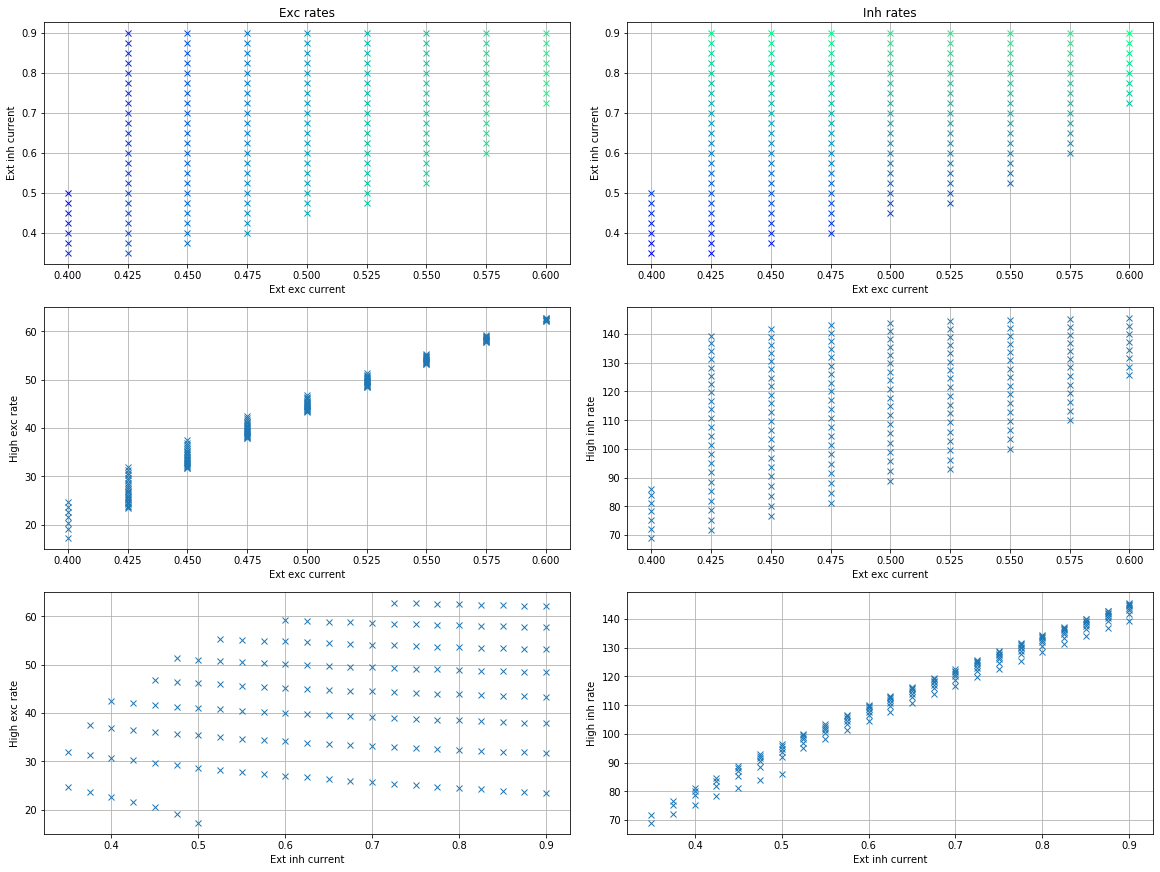

In [6]:
cmap = colormaps.get_cmap('winter')

fig0, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(up_rates_norm[i,0]), label='normalized high rates')
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(up_rates_norm[i,1]), label='normalized high rates')
    
#ax[0,0,].legend()
#ax[0,1].legend()
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, up_rates[:,0], 'x')
ax[1,1].plot(ext_exc, up_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('High exc rate')
ax[1,1].set_ylabel('High inh rate')
ax[2,0].plot(ext_inh, up_rates[:,0], 'x')
ax[2,1].plot(ext_inh, up_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('High exc rate')
ax[2,1].set_ylabel('High inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

- excitatory high rates are mainly determined by the external excitatory current
- inhibitory high rates are mainly determined by the external inhibitory current

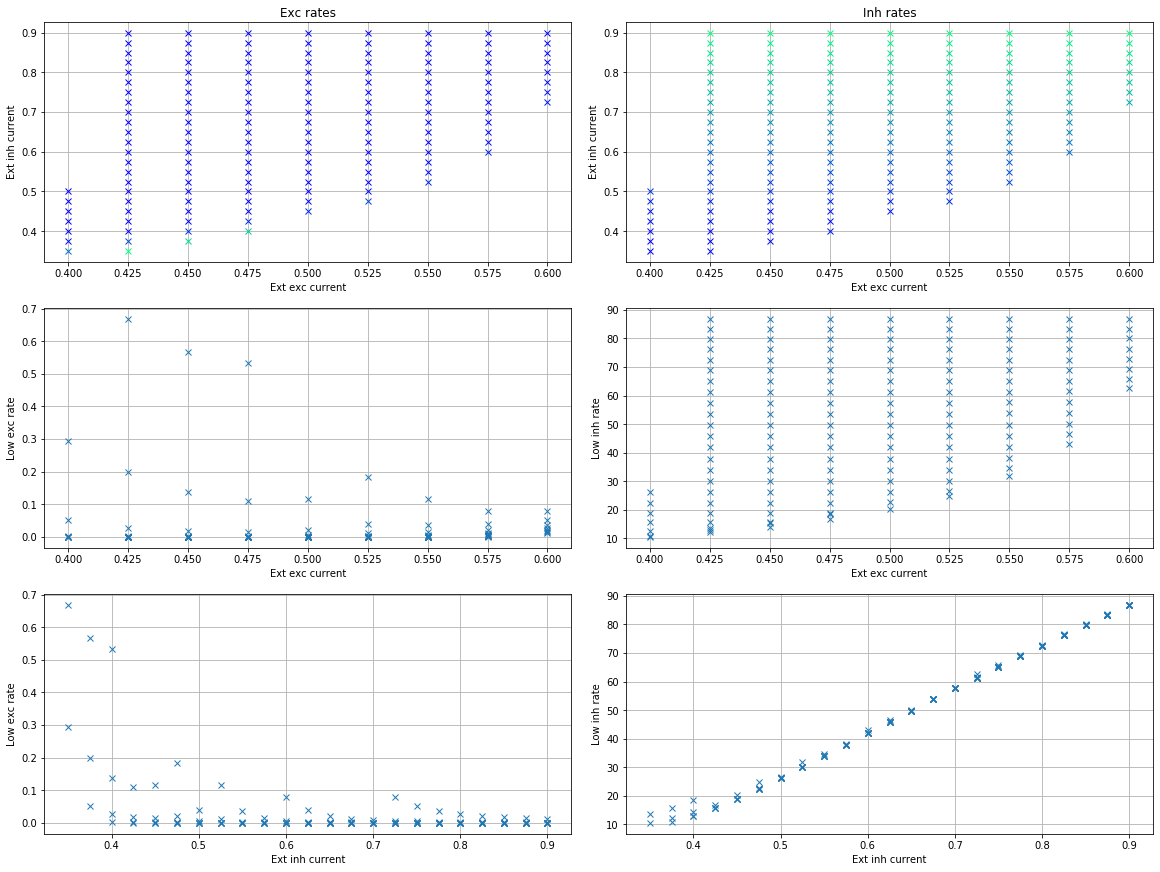

In [7]:
fig1, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(down_rates_norm[i,0]))
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(down_rates_norm[i,1]))
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, down_rates[:,0], 'x')
ax[1,1].plot(ext_exc, down_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('Low exc rate')
ax[1,1].set_ylabel('Low inh rate')
ax[2,0].plot(ext_inh, down_rates[:,0], 'x')
ax[2,1].plot(ext_inh, down_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('Low exc rate')
ax[2,1].set_ylabel('Low inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

- excitatory low rates are close to zero in all cases
- inhibitory low rates are mainly determined by depend on external inhibitory current
- distance between high and low inhibitory rates slightly decreases with higher external inhibitory currents

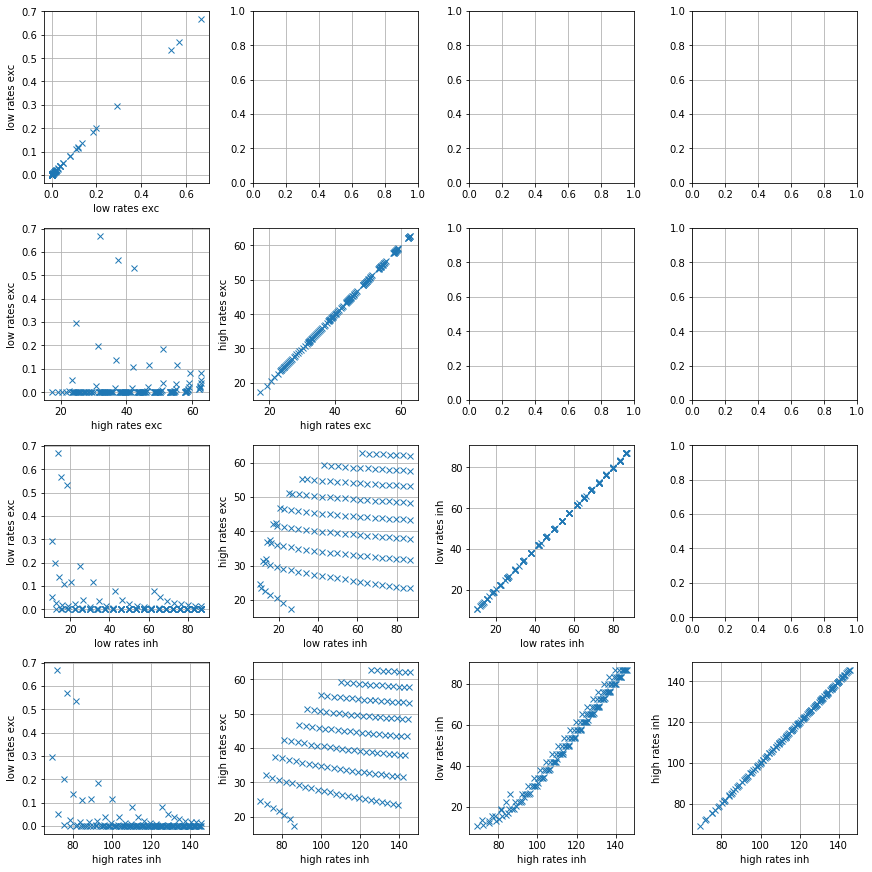

In [8]:
fig2, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (12,12) )
ax[0,0].plot(down_rates[:,0], down_rates[:,0], 'x')
ax[0,0].set_xlabel('low rates exc')
ax[0,0].set_ylabel('low rates exc')

ax[1,0].plot(up_rates[:,0], down_rates[:,0], 'x')
ax[1,0].set_xlabel('high rates exc')
ax[1,0].set_ylabel('low rates exc')

ax[1,1].plot(up_rates[:,0], up_rates[:,0], 'x')
ax[1,1].set_xlabel('high rates exc')
ax[1,1].set_ylabel('high rates exc')

ax[2,0].plot(down_rates[:,1], down_rates[:,0], 'x')
ax[2,0].set_xlabel('low rates inh')
ax[2,0].set_ylabel('low rates exc')

ax[2,1].plot(down_rates[:,1], up_rates[:,0], 'x')
ax[2,1].set_xlabel('low rates inh')
ax[2,1].set_ylabel('high rates exc')

ax[2,2].plot(down_rates[:,1], down_rates[:,1], 'x')
ax[2,2].set_xlabel('low rates inh')
ax[2,2].set_ylabel('low rates inh')

ax[3,0].plot(up_rates[:,1], down_rates[:,0], 'x')
ax[3,0].set_xlabel('high rates inh')
ax[3,0].set_ylabel('low rates exc')

ax[3,1].plot(up_rates[:,1], up_rates[:,0], 'x')
ax[3,1].set_xlabel('high rates inh')
ax[3,1].set_ylabel('high rates exc')

ax[3,2].plot(up_rates[:,1], down_rates[:,1], 'x')
ax[3,2].set_xlabel('high rates inh')
ax[3,2].set_ylabel('low rates inh')

ax[3,3].plot(up_rates[:,1], up_rates[:,1], 'x')
ax[3,3].set_xlabel('high rates inh')
ax[3,3].set_ylabel('high rates inh')

plt.show()

- high and low inhibitory rates are strongly correlated

### Differences between up and down states in rates

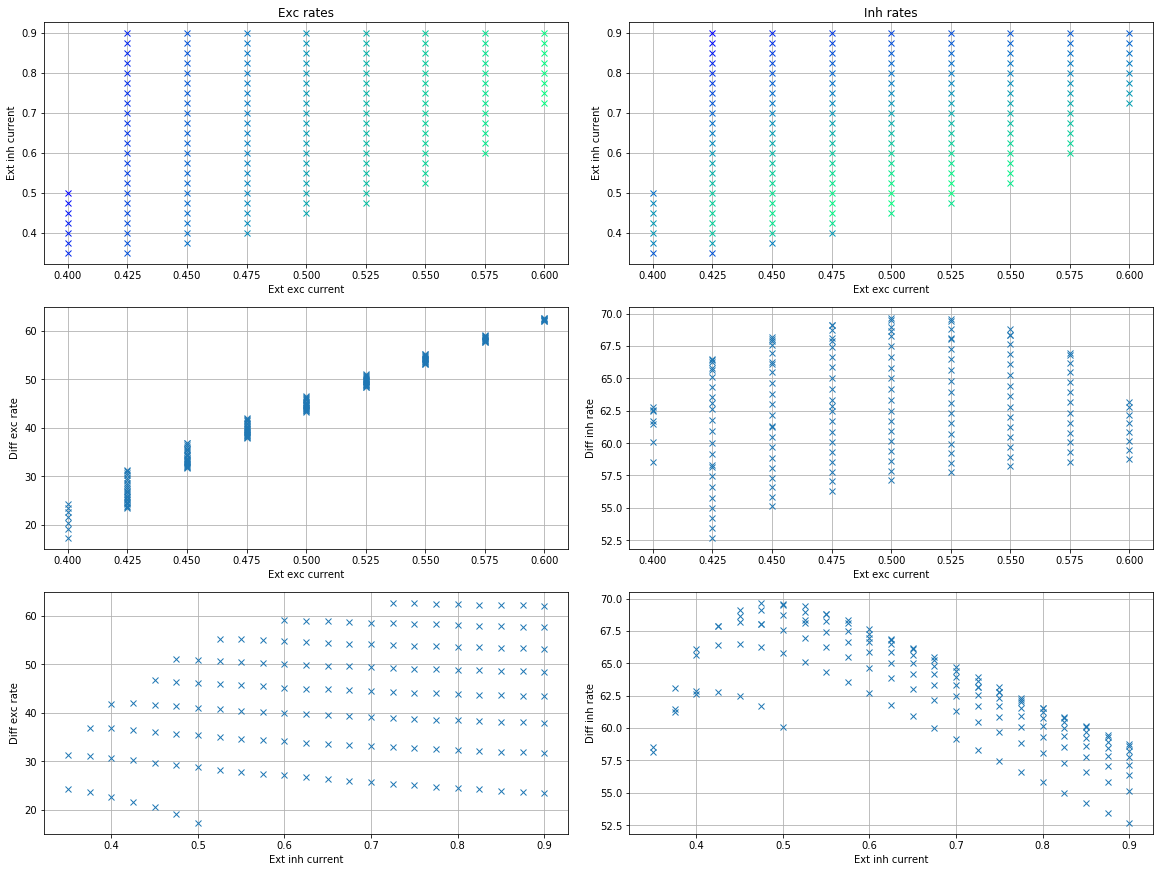

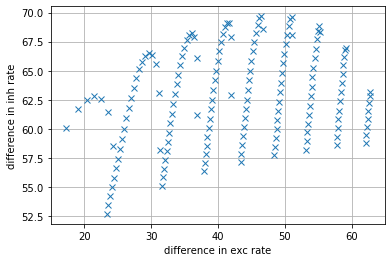

In [9]:
cmap = colormaps.get_cmap('winter')
fig2, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(diff_rates_norm[i,0]))
    ax[0,1].plot(ext_exc[i], ext_inh[i], 'x', color = cmap(diff_rates_norm[i,1]))
 
ax[0,0].set_xlabel('Ext exc current')
ax[0,1].set_xlabel('Ext exc current')
ax[0,0].set_ylabel('Ext inh current')
ax[0,1].set_ylabel('Ext inh current')

ax[1,0].plot(ext_exc, diff_rates[:,0], 'x')
ax[1,1].plot(ext_exc, diff_rates[:,1], 'x')
ax[1,0].set_xlabel('Ext exc current')
ax[1,1].set_xlabel('Ext exc current')
ax[1,0].set_ylabel('Diff exc rate')
ax[1,1].set_ylabel('Diff inh rate')
ax[2,0].plot(ext_inh, diff_rates[:,0], 'x')
ax[2,1].plot(ext_inh, diff_rates[:,1], 'x')
ax[2,0].set_xlabel('Ext inh current')
ax[2,1].set_xlabel('Ext inh current')
ax[2,0].set_ylabel('Diff exc rate')
ax[2,1].set_ylabel('Diff inh rate')

cols = ['Exc rates', 'Inh rates']
pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

plt.show()

plt.plot(diff_rates[:,0], diff_rates[:,1], 'x')
plt.xlabel('difference in exc rate')
plt.ylabel('difference in inh rate')
plt.show()

- external excitatory current determines the difference in the excitatory rate between up and down state
- external inhibitory current determines the difference in the inhibitory rate between up and down state except for the low region close to the oscillatory regime

### Dependence of difference in rates on distance to regime boundary

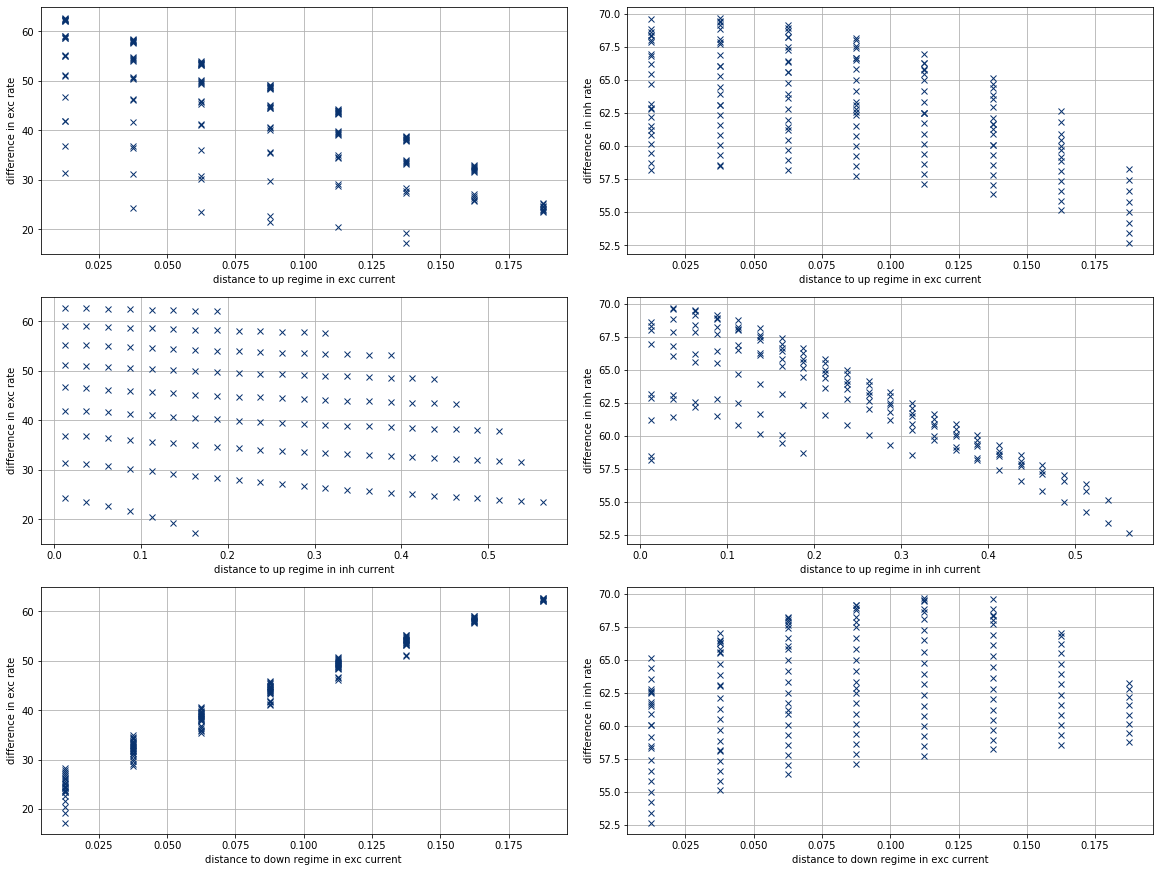

In [10]:
cmap = colormaps.get_cmap('Blues')
fig3, ax = plt.subplots(3, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(dist_up_regime[i,0], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[0,1].plot(dist_up_regime[i,0], diff_rates[i,1], 'x', color=cmap(0.99))
    ax[1,0].plot(dist_up_regime[i,1], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[1,1].plot(dist_up_regime[i,1], diff_rates[i,1], 'x', color=cmap(0.99))
    ax[2,0].plot(dist_down_regime[i], diff_rates[i,0], 'x', color=cmap(0.99))
    ax[2,1].plot(dist_down_regime[i], diff_rates[i,1], 'x', color=cmap(0.99))
        
ax[0,0].set_xlabel('distance to up regime in exc current')
ax[0,0].set_ylabel('difference in exc rate')
ax[0,1].set_xlabel('distance to up regime in exc current')
ax[0,1].set_ylabel('difference in inh rate')
ax[1,0].set_xlabel('distance to up regime in inh current')
ax[1,0].set_ylabel('difference in exc rate')
ax[1,1].set_xlabel('distance to up regime in inh current')
ax[1,1].set_ylabel('difference in inh rate')
ax[2,0].set_xlabel('distance to down regime in exc current')
ax[2,0].set_ylabel('difference in exc rate')
ax[2,1].set_xlabel('distance to down regime in exc current')
ax[2,1].set_ylabel('difference in inh rate')

plt.show()

- high horizontal distance only works for low external excitatory current
- high vertical distance only works for high external inhibitory currents, where gap between high and low state decreases

### Dependence of distance to attractor in rate on distance to regime boundary and on difference in rates

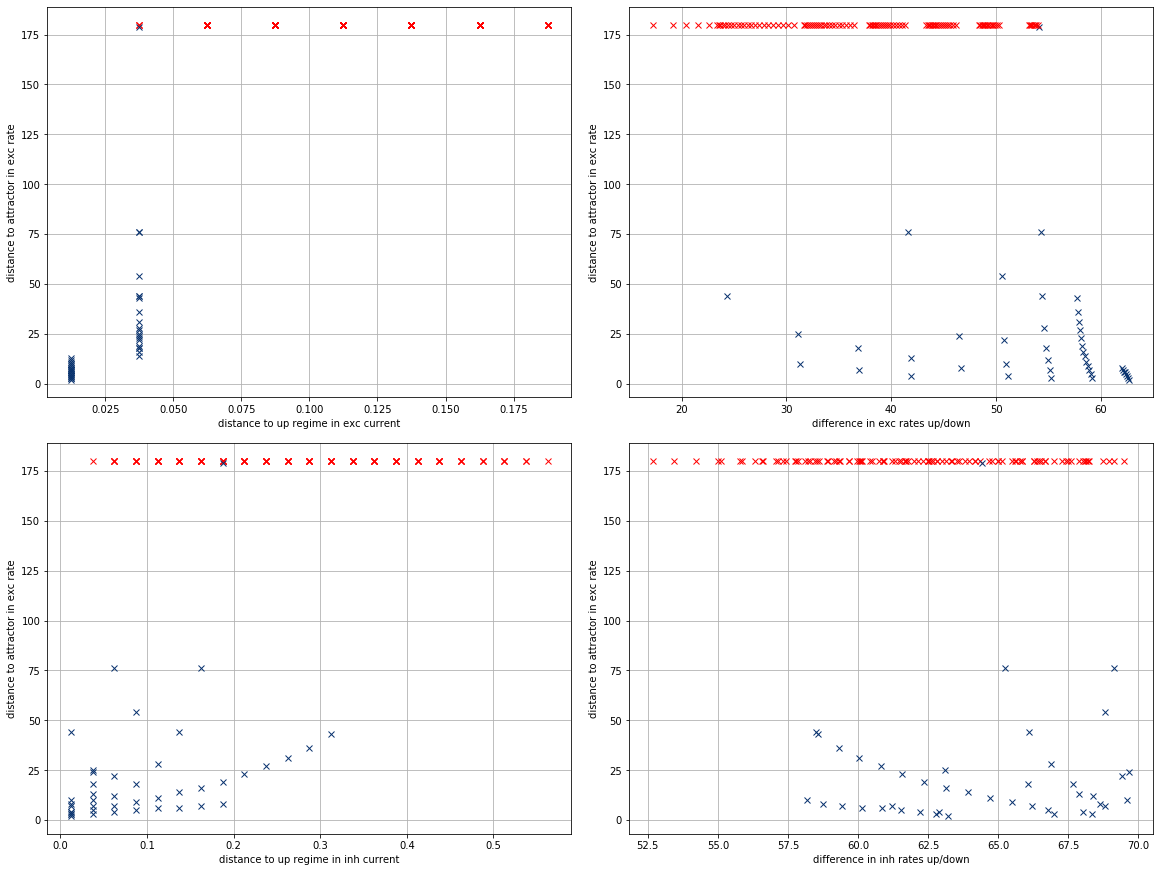

In [11]:
cmap = colormaps.get_cmap('Blues')
fig4, ax = plt.subplots(2, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    if dist_attractor_rate_norm[i,0] <= 1.:
        ax[0,0].plot(dist_up_regime[i,0], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
        ax[0,1].plot(diff_rates[i,0], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
        ax[1,0].plot(dist_up_regime[i,1], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
        ax[1,1].plot(diff_rates[i,1], dist_attractor_rate[i,0], 'x', color=cmap(0.99))
    else:
        ax[0,0].plot(dist_up_regime[i,0], 180., 'x', color='red')
        ax[0,1].plot(diff_rates[i,0], 180., 'x', color='red')
        ax[1,0].plot(dist_up_regime[i,1], 180., 'x', color='red')
        ax[1,1].plot(diff_rates[i,1], 180., 'x', color='red')
        
ax[0,0].set_xlabel('distance to up regime in exc current')
ax[0,0].set_ylabel('distance to attractor in exc rate')
ax[0,1].set_xlabel('difference in exc rates up/down')
ax[0,1].set_ylabel('distance to attractor in exc rate')
ax[1,0].set_xlabel('distance to up regime in inh current')
ax[1,0].set_ylabel('distance to attractor in exc rate')
ax[1,1].set_xlabel('difference in inh rates up/down')
ax[1,1].set_ylabel('distance to attractor in exc rate')
plt.show()

What determines if and at which rate we are attracted towards the up state?
- slight tendency to higher rates at higher distance in current space
- slight tendency to higher rates ar lower difference in rate space

$\rightarrow$ "distance to attractor" is nothing to easily work with

### Dependence of distance to attractor in percent on distance to regime boundary and on difference in rates

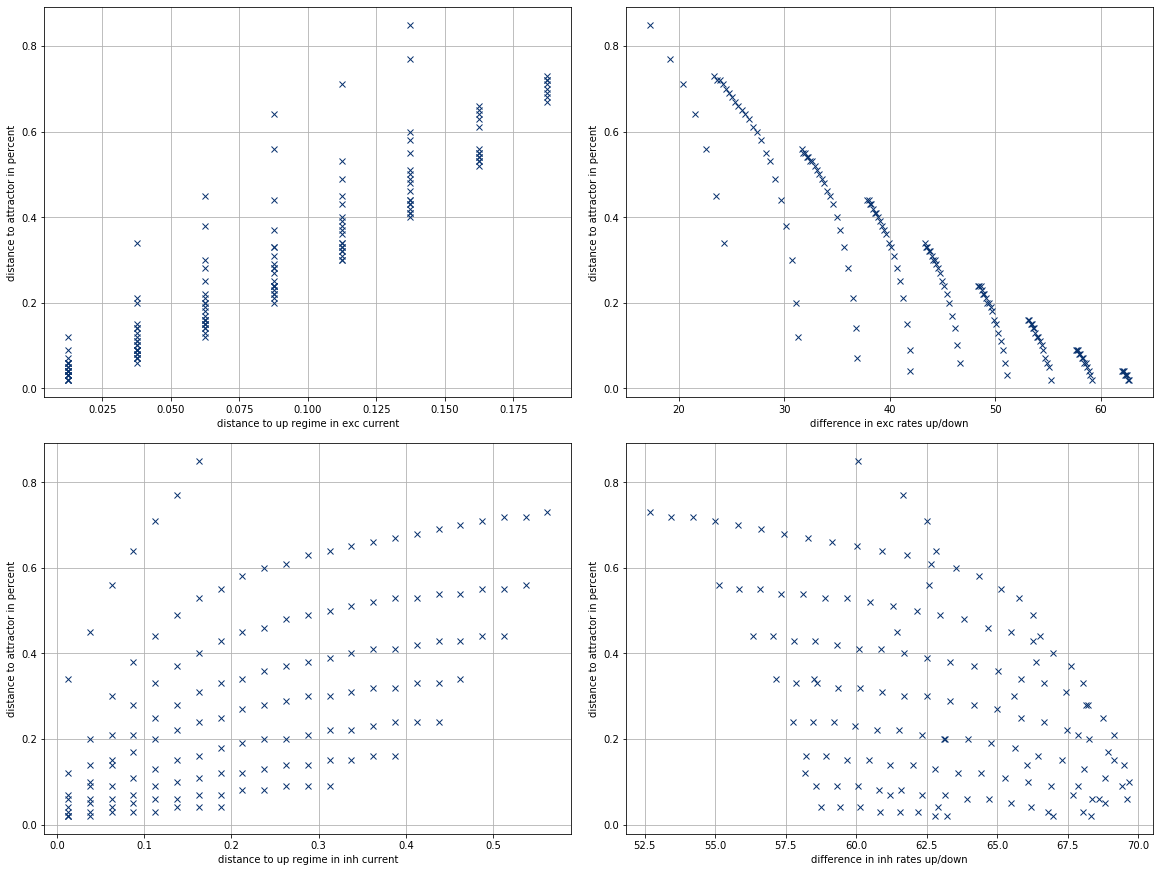

In [12]:
cmap = colormaps.get_cmap('Blues')
fig4, ax = plt.subplots(2, 2, constrained_layout=True, figsize = (16,12) )

for i in range(len(ext_exc)):
    ax[0,0].plot(dist_up_regime[i,0], dist_attractor_rate_perc[i], 'x', color=cmap(0.99))
    ax[0,1].plot(diff_rates[i,0], dist_attractor_rate_perc[i], 'x', color=cmap(0.99))
    ax[1,0].plot(dist_up_regime[i,1], dist_attractor_rate_perc[i], 'x', color=cmap(0.99))
    ax[1,1].plot(diff_rates[i,1], dist_attractor_rate_perc[i], 'x', color=cmap(0.99))

        
ax[0,0].set_xlabel('distance to up regime in exc current')
ax[0,0].set_ylabel('distance to attractor in percent')
ax[0,1].set_xlabel('difference in exc rates up/down')
ax[0,1].set_ylabel('distance to attractor in percent')
ax[1,0].set_xlabel('distance to up regime in inh current')
ax[1,0].set_ylabel('distance to attractor in percent')
ax[1,1].set_xlabel('difference in inh rates up/down')
ax[1,1].set_ylabel('distance to attractor in percent')
plt.show()

In [27]:
def readcase(case_):
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global d_x, d_y, diff_x1, diff_y1, diff_x2, diff_y2, cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    global d_attr_1, d_attr_2
    
    readpath = '.' + os.sep + 'data' + os.sep + str(case_[:5]) + os.sep

    data_array = data.read_data(readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_cost = control_data[3]
    
    d_x = []
    d_y = []
    
    if case_[0] == '0':
        for i in range(len(exc_1)):
            d_x.append(data.dist_right(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_low(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
            diff_x1.append(diff_rates[i,0])
            diff_y1.append(diff_rates[i,1])
    else:
        for i in range(len(exc_1)):
            d_x.append(data.dist_left(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_up(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
            
    diff_x1 = []
    diff_x2 = []
    diff_y1 = []
    diff_y2 = []
    
    for i in range(len(exc_1)):
        diff_x1.append(diff_rates[i,0])
        diff_y1.append(diff_rates[i,1])
    for i in range(len(exc_2)):
        diff_x2.append(diff_rates[i,0])
        diff_y2.append(diff_rates[i,1])
        
    cost_p_x = []
    cost_p_y = []
    cost_s_x = []
    cost_e_x = []
    cost_s_y = []
    cost_e_y = []

    for i in range(len(d_x)):
        cost_p_x.append(cost1[i][0][0][0])
        cost_s_x.append(cost1[i][2][0][0])
        cost_e_x.append(cost1[i][1][0][0])
    for i in range(len(d_y)):
        cost_p_y.append(cost2[i][0][0][1])
        cost_s_y.append(cost2[i][2][0][1])
        cost_e_y.append(cost2[i][1][0][1])
                
    d_attr_1 = []
    d_attr_2 = []
    for i in range(len(ext_exc)):
        for j in range(len(exc_1)):
            if exc_1[j] == ext_exc[i] and inh_1[j] == ext_inh[i]:
                d_attr_1.append(dist_attractor_rate_perc[i])
                
    for i in range(len(ext_exc)):
        for j in range(len(exc_2)):
            if exc_2[j] == ext_exc[i] and inh_2[j] == ext_inh[i]:
                #print(i, j, exc_2[j], ext_exc[i], inh_2[j], ext_inh[i])
                d_attr_2.append(dist_attractor_rate_perc[i])

### maximum amplitude as a function of distance to regime boundary, sparsity enforced

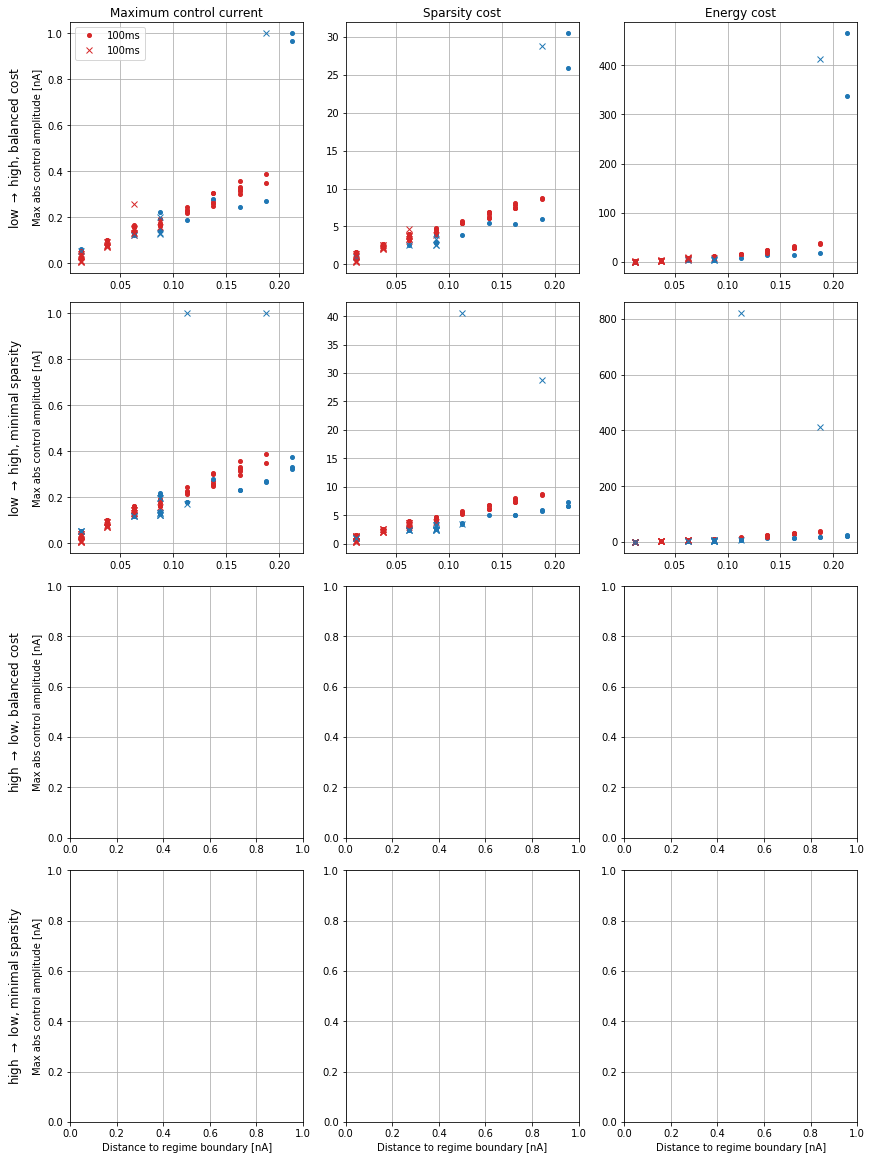

In [42]:
fig5, ax = plt.subplots(4, 3, constrained_layout=True, figsize = (12,16) )

#########################################
for c in ['00000', '00010', '00020']:
    readcase(c)
    ax[0,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[0,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[0,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[0,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[0,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[0,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)
    
for c in ['00001', '00011', '00021']:
    readcase(c)
    ax[0,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[0,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[0,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[0,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[0,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[0,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)


#########################################
for c in ['00100', '00110', '00120']:
    readcase(c)
    ax[1,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[1,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[1,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[1,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[1,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[1,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)

for c in ['00101', '00111', '00121']:
    readcase(c)
    ax[1,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[1,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[1,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[1,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[1,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[1,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)

"""
#########################################
for c in ['10000', '10010', '10020']:
    readcase(c)
    ax[2,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[2,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[2,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[2,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[2,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[2,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)
    
for c in ['10001', '10011', '10021']:
    readcase(c)
    ax[2,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[2,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[2,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[2,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[2,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[2,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)

#########################################
for c in ['10100', '10110', '10120']:
    readcase(c)
    ax[3,0].plot(d_x, lenx_1, 'o', color=exc_red, markersize=4)
    ax[3,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[3,1].plot(d_x, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[3,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)
    ax[3,2].plot(d_x, cost_e_x, 'o', color=exc_red, markersize=4)
    ax[3,2].plot(d_y, cost_e_y, 'o', color=inh_blue, markersize=4)
    
for c in ['10101', '10111', '10121']:
    readcase(c)
    ax[3,0].plot(d_x, lenx_1, 'x', color=exc_red, markersize=6)
    ax[3,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[3,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[3,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)
    ax[3,2].plot(d_x, cost_e_x, 'x', color=exc_red, markersize=6)
    ax[3,2].plot(d_y, cost_e_y, 'x', color=inh_blue, markersize=6)
"""

ax[3,0].set_xlabel("Distance to regime boundary [nA]")
ax[3,1].set_xlabel("Distance to regime boundary [nA]")
ax[3,2].set_xlabel("Distance to regime boundary [nA]")
ax[0,0].set_ylabel("Max abs control amplitude [nA]")
ax[1,0].set_ylabel("Max abs control amplitude [nA]")
ax[2,0].set_ylabel("Max abs control amplitude [nA]")
ax[3,0].set_ylabel("Max abs control amplitude [nA]")

label_100 = mlines.Line2D([], [], color=exc_red, marker='o', linestyle='None',
                          markersize=4, label='100ms')
label_400 = mlines.Line2D([], [], color=exc_red, marker='x', linestyle='None',
                          markersize=6, label='100ms')

ax[0,0].legend(handles=[label_100, label_400])

cols = ['Maximum control current', 'Sparsity cost', 'Energy cost']
rows = [r'low $\rightarrow$ high, balanced cost', r'low $\rightarrow$ high, minimal sparsity',
        r'high $\rightarrow$ low, balanced cost', r'high $\rightarrow$ low, minimal sparsity']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.savefig( os.path.join(os.getcwd(), 'ampl_dist.png') )
plt.show()

### Maximum amplitude as a function of difference in exc rate

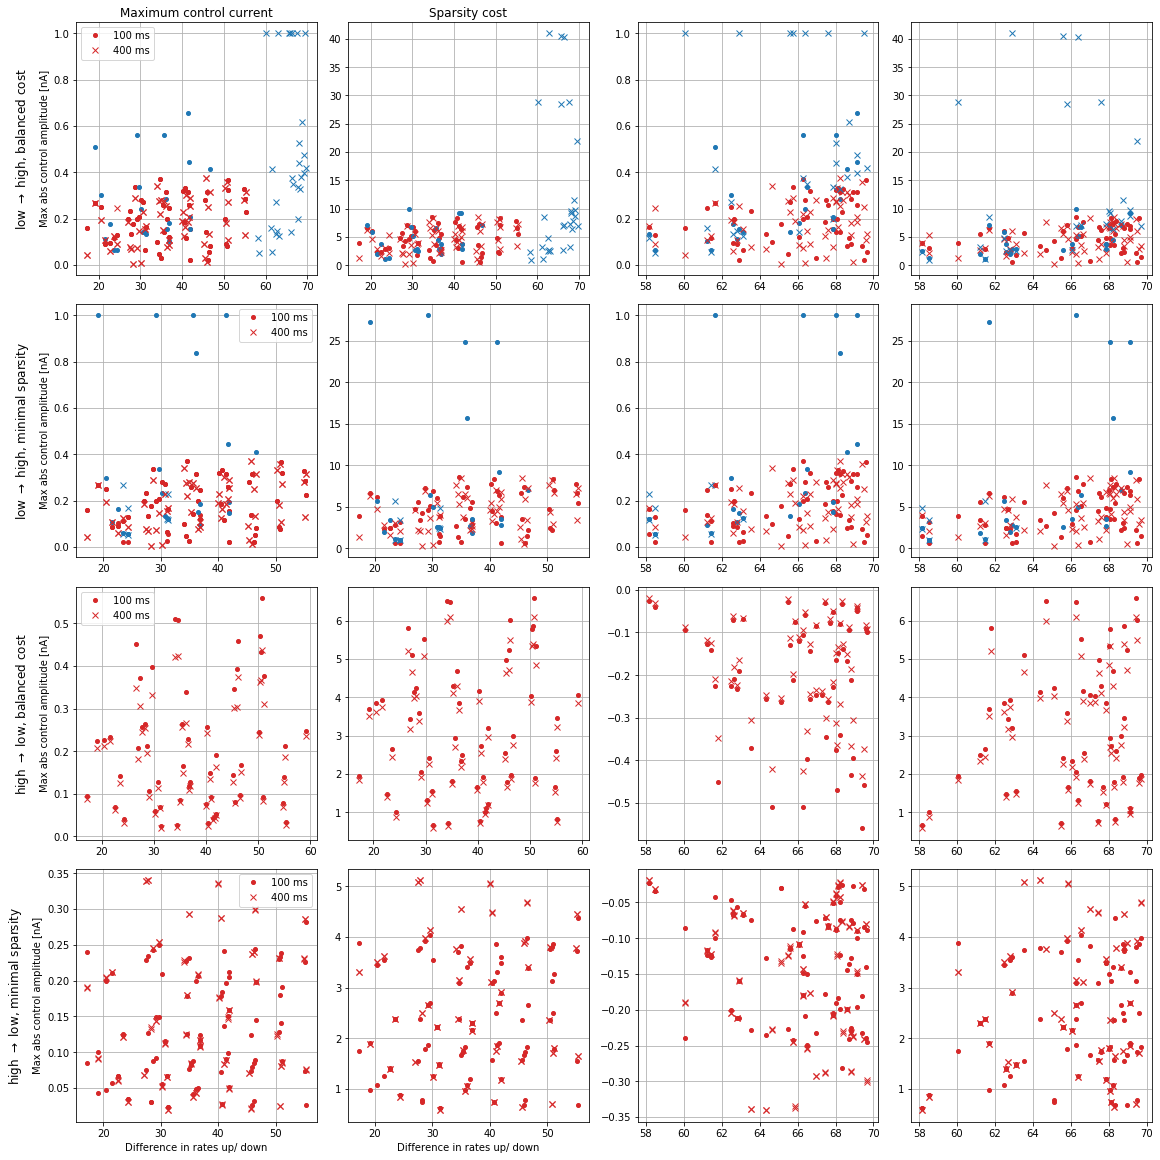

In [29]:
fig5, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (16,16) )

#########################################
readcase('00000')

ax[0,0].plot(diff_x1, lenx_1, 'o', color=exc_red, markersize=4, label='100 ms')

for case_ in ['00000', '00010']:
    readcase(case_)
    ax[0,0].plot(diff_x1, lenx_1, 'o', color=exc_red, markersize=4)
    ax[0,0].plot(diff_x2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[0,1].plot(diff_x1, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[0,1].plot(diff_x2, cost_s_y, 'o', color=inh_blue, markersize=4)

    ax[0,2].plot(diff_y1, lenx_1, 'o', color=exc_red, markersize=4)
    ax[0,2].plot(diff_y2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[0,3].plot(diff_y1, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[0,3].plot(diff_y2, cost_s_y, 'o', color=inh_blue, markersize=4)
    

readcase('00001')

ax[0,0].plot(diff_x1, lenx_1, 'x', color=exc_red, markersize=6, label='400 ms')
for case_ in ['00001', '00011']:
    readcase(case_)
    
    ax[0,0].plot(diff_x1, lenx_1, 'x', color=exc_red, markersize=6)
    ax[0,0].plot(diff_y2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[0,1].plot(diff_x1, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[0,1].plot(diff_y2, cost_s_y, 'x', color=inh_blue, markersize=6)

    ax[0,2].plot(diff_y1, lenx_1, 'x', color=exc_red, markersize=6)
    ax[0,2].plot(diff_y2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[0,3].plot(diff_y1, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[0,3].plot(diff_y2, cost_s_y, 'x', color=inh_blue, markersize=6)

#########################################
readcase('00000max')

ax[1,0].plot(diff_x1, lenx_1, 'o', color=exc_red, markersize=4, label='100 ms')

for case_ in ['00000max', '00010max']:
    readcase(case_)
    ax[1,0].plot(diff_x1, lenx_1, 'o', color=exc_red, markersize=4)
    ax[1,0].plot(diff_x2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[1,1].plot(diff_x1, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[1,1].plot(diff_x2, cost_s_y, 'o', color=inh_blue, markersize=4)

    ax[1,2].plot(diff_y1, lenx_1, 'o', color=exc_red, markersize=4)
    ax[1,2].plot(diff_y2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
    ax[1,3].plot(diff_y1, cost_s_x, 'o', color=exc_red, markersize=4)
    ax[1,3].plot(diff_y2, cost_s_y, 'o', color=inh_blue, markersize=4)

readcase('00001max')

ax[1,0].plot(diff_x1, lenx_1, 'x', color=exc_red, markersize=6, label='400 ms')

for case_ in ['00001max', '00011max']:
    readcase(case_)
    
    ax[1,0].plot(diff_x1, lenx_1, 'x', color=exc_red, markersize=6)
    ax[1,0].plot(diff_x2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[1,1].plot(diff_x1, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[1,1].plot(diff_x2, cost_s_y, 'x', color=inh_blue, markersize=6)

    ax[1,2].plot(diff_y1, lenx_1, 'x', color=exc_red, markersize=6)
    ax[1,2].plot(diff_y2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
    ax[1,3].plot(diff_y1, cost_s_x, 'x', color=exc_red, markersize=6)
    ax[1,3].plot(diff_y2, cost_s_y, 'x', color=inh_blue, markersize=6)

#########################################
readcase('10000')

ax[2,0].plot(diff_x1, np.abs(lenx_1), 'o', color=exc_red, markersize=4, label='100 ms')
ax[2,0].plot(diff_x2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[2,1].plot(diff_x1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[2,1].plot(diff_x2, cost_s_y, 'o', color=inh_blue, markersize=4)

ax[2,2].plot(diff_y1, lenx_1, 'o', color=exc_red, markersize=4)
ax[2,2].plot(diff_y2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[2,3].plot(diff_y1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[2,3].plot(diff_y2, cost_s_y, 'o', color=inh_blue, markersize=4)

readcase('10010')

ax[2,0].plot(diff_x1, np.abs(lenx_1), 'o', color=exc_red, markersize=4)
ax[2,0].plot(diff_x2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[2,1].plot(diff_x1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[2,1].plot(diff_x2, cost_s_y, 'o', color=inh_blue, markersize=4)

ax[2,2].plot(diff_y1, lenx_1, 'o', color=exc_red, markersize=4)
ax[2,2].plot(diff_y2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[2,3].plot(diff_y1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[2,3].plot(diff_y2, cost_s_y, 'o', color=inh_blue, markersize=4)

readcase('10001')

ax[2,0].plot(diff_x1, np.abs(lenx_1), 'x', color=exc_red, markersize=6, label='400 ms')
ax[2,0].plot(diff_x2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[2,1].plot(diff_x1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[2,1].plot(diff_x2, cost_s_y, 'x', color=inh_blue, markersize=6)

ax[2,2].plot(diff_y1, lenx_1, 'x', color=exc_red, markersize=6)
ax[2,2].plot(diff_y2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[2,3].plot(diff_y1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[2,3].plot(diff_y2, cost_s_y, 'x', color=inh_blue, markersize=6)

readcase('10011')

ax[2,0].plot(diff_x1, np.abs(lenx_1), 'x', color=exc_red, markersize=6)
ax[2,0].plot(diff_x2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[2,1].plot(diff_x1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[2,1].plot(diff_x2, cost_s_y, 'x', color=inh_blue, markersize=6)

ax[2,2].plot(diff_y1, lenx_1, 'x', color=exc_red, markersize=6)
ax[2,2].plot(diff_y2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[2,3].plot(diff_y1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[2,3].plot(diff_y2, cost_s_y, 'x', color=inh_blue, markersize=6)

############################################################
readcase('10000max')

ax[3,0].plot(diff_x1, np.abs(lenx_1), 'o', color=exc_red, markersize=4, label='100 ms')
ax[3,0].plot(d_y, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[3,1].plot(diff_x1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[3,1].plot(d_y, cost_s_y, 'o', color=inh_blue, markersize=4)

ax[3,2].plot(diff_y1, lenx_1, 'o', color=exc_red, markersize=4)
ax[3,2].plot(diff_y2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[3,3].plot(diff_y1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[3,3].plot(diff_y2, cost_s_y, 'o', color=inh_blue, markersize=4)

readcase('10010max')

ax[3,0].plot(diff_x1, np.abs(lenx_1), 'o', color=exc_red, markersize=4)
ax[3,0].plot(diff_x2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[3,1].plot(diff_x1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[3,1].plot(diff_x2, cost_s_y, 'o', color=inh_blue, markersize=4)

ax[3,2].plot(diff_y1, lenx_1, 'o', color=exc_red, markersize=4)
ax[3,2].plot(diff_y2, np.abs(leny_2), 'o', color=inh_blue, markersize=4)
ax[3,3].plot(diff_y1, cost_s_x, 'o', color=exc_red, markersize=4)
ax[3,3].plot(diff_y2, cost_s_y, 'o', color=inh_blue, markersize=4)

readcase('10001max')

ax[3,0].plot(diff_x1, np.abs(lenx_1), 'x', color=exc_red, markersize=6, label='400 ms')
ax[3,0].plot(diff_x2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[3,1].plot(diff_x1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[3,1].plot(diff_x2, cost_s_y, 'x', color=inh_blue, markersize=6)

ax[3,2].plot(diff_y1, lenx_1, 'x', color=exc_red, markersize=6)
ax[3,2].plot(diff_y2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[3,3].plot(diff_y1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[3,3].plot(diff_y2, cost_s_y, 'x', color=inh_blue, markersize=6)

readcase('10011max')

ax[3,0].plot(diff_x1, np.abs(lenx_1), 'x', color=exc_red, markersize=6)
ax[3,0].plot(diff_x2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[3,1].plot(diff_x1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[3,1].plot(diff_x2, cost_s_y, 'x', color=inh_blue, markersize=6)

ax[3,2].plot(diff_y1, lenx_1, 'x', color=exc_red, markersize=6)
ax[3,2].plot(diff_y2, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[3,3].plot(diff_y1, cost_s_x, 'x', color=exc_red, markersize=6)
ax[3,3].plot(diff_y2, cost_s_y, 'x', color=inh_blue, markersize=6)

ax[0,0].legend()
ax[1,0].legend()
ax[2,0].legend()
ax[3,0].legend()

ax[3,0].set_xlabel("Difference in rates up/ down")
ax[3,1].set_xlabel("Difference in rates up/ down")
ax[0,0].set_ylabel("Max abs control amplitude [nA]")
ax[1,0].set_ylabel("Max abs control amplitude [nA]")
ax[2,0].set_ylabel("Max abs control amplitude [nA]")
ax[3,0].set_ylabel("Max abs control amplitude [nA]")

cols = ['Maximum control current', 'Sparsity cost']
rows = [r'low $\rightarrow$ high, balanced cost', r'low $\rightarrow$ high, minimal sparsity',
        r'high $\rightarrow$ low, balanced cost', r'high $\rightarrow$ low, minimal sparsity']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.show()

### Two-node and one-node solutions in sparsity-restricted state switching

low $\rightarrow$ high, balanced cost, 100ms
case =  00000
case =  00010
case =  00020
low $\rightarrow$ high, balanced cost, 400ms
case =  00001
case =  00011
case =  00021


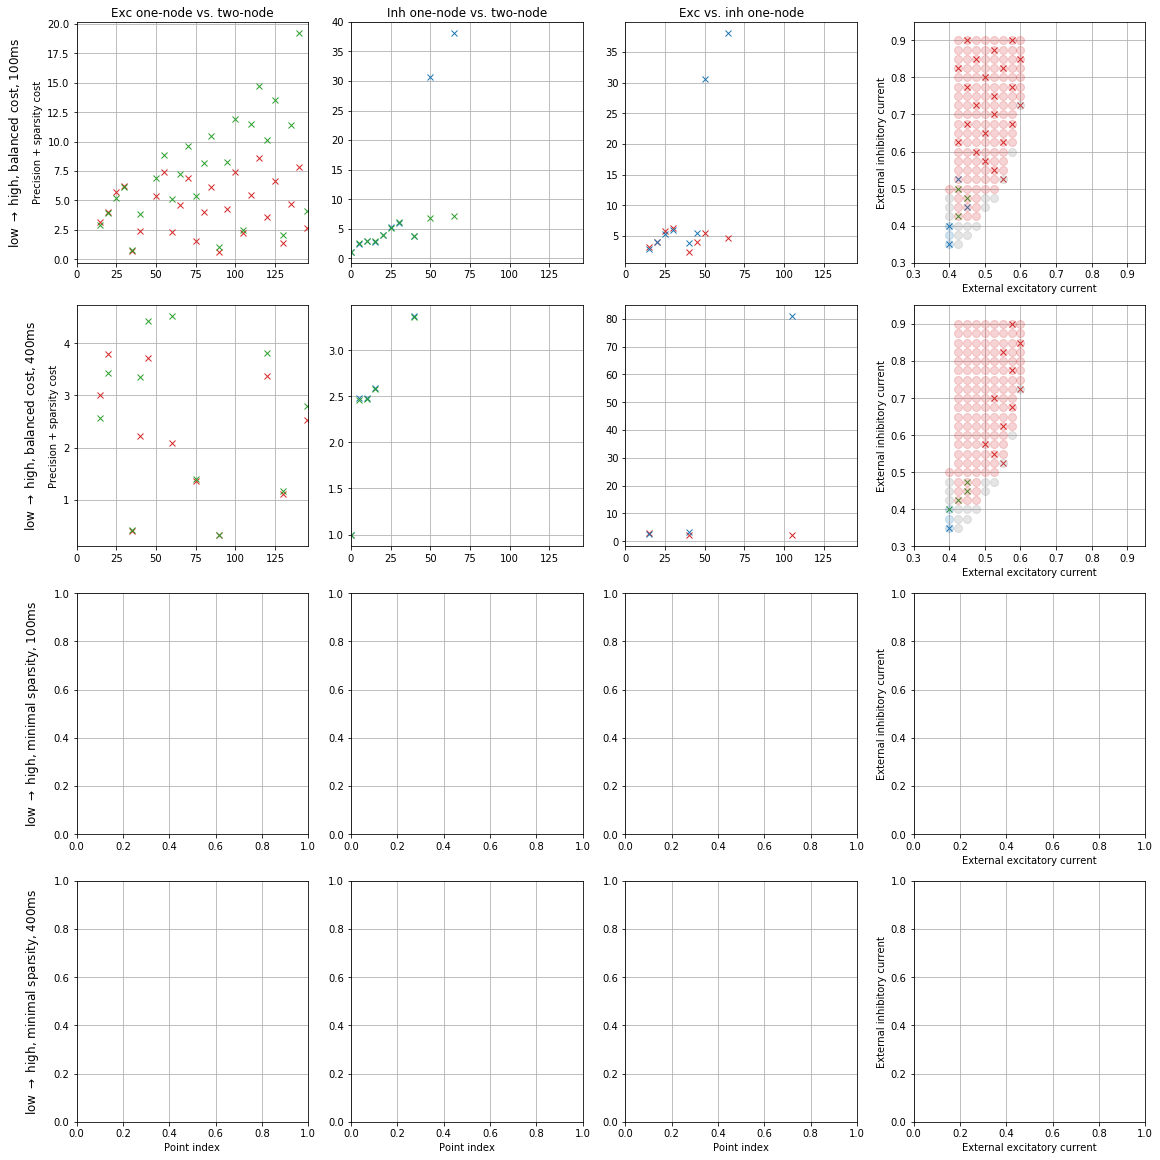

In [55]:
fig7, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (16,16) )

rows = [r'low $\rightarrow$ high, balanced cost, 100ms', r'low $\rightarrow$ high, balanced cost, 400ms',
        r'low $\rightarrow$ high, minimal sparsity, 100ms', r'low $\rightarrow$ high, minimal sparsity, 400ms']

cases = [['00000', '00010', '00020'], ['00001', '00011', '00021']]#, '00031', '00041', '00051'],
         #['00100', '00110', '00120'], ['00101', '00111', '00121', '00131', '00141', '00151']]

alpha_val = 0.2

for k in range(len(cases)):
    print(rows[k])
    print("case = ", cases[k][0])
    readcase(cases[k][0])
    cost_index = np.zeros(( len(ext_exc), 4 ))

    for i in range(len(ext_exc)):
        cost_index[i,0] = i
        for j in range(len(exc_)):
            if exc_[j] == i:
                cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                if cost_index[i,1] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,1])
        for j in range(len(inh_)):
            if inh_[j] == i:
                cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                if cost_index[i,2] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,2])
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                if cost_index[i,3] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,3])
            
    for k_ in range(1, len(cases[k])):
        print("case = ", cases[k][k_])
        readcase(cases[k][k_])

        for i in range(len(ext_exc)):
            for j in range(len(exc_)):
                if exc_[j] == i:
                    if cost_index[i,1] == 0.:
                        cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                    elif cost_index[i,1] > cost1[j][0][0][0] + cost1[j][2][0][0]:
                        cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                        #print("1 cost index already set, ", cost_index[i,1], cost1[j][0][0][0] + cost1[j][2][0][0])
                    if cost_index[i,1] > 200.:
                        print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,1])
            for j in range(len(inh_)):
                if inh_[j] == i:
                    if cost_index[i,2] == 0.:
                        cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                    elif cost_index[i,2] > cost2[j][0][0][0] + cost2[j][2][0][1]:
                        cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                        #print("2 cost index already set, ", cost_index[i,2], cost2[j][0][0][0] + cost2[j][2][0][1])
                    if cost_index[i,2] > 200.:
                        print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,2])
            for j in range(len(both_c_)):
                if both_c_[j] == i:
                    if cost_index[i,3] == 0.:
                        cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                    elif cost_index[i,3] > ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] ):
                        cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                        #print("3 cost index already set, ", cost_index[i,3], cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                    if cost_index[i,3] > 200.:
                        print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,3])

    for i in range(cost_index.shape[0]):
        if cost_index[i,1] != 0. and cost_index[i,3] != 0.:
            ax[k,0].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,0].plot(i, cost_index[i,3], 'x', color=green)
        if cost_index[i,2] != 0. and cost_index[i,3] != 0.:
            ax[k,1].plot(i, cost_index[i,2], 'x', color=inh_blue)
            ax[k,1].plot(i, cost_index[i,3], 'x', color=green)
        if cost_index[i,1] != 0. and cost_index[i,2] != 0.:
            ax[k,2].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,2].plot(i, cost_index[i,2], 'x', color=inh_blue)
        
        if cost_index[i,1] != 0. and cost_index[i,2] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,2] and cost_index[i,1] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,3] < cost_index[i,1] and cost_index[i,3] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,1] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,1] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,3] < cost_index[i,1]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,3] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,3] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            elif cost_index[i,2] < cost_index[i,3]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0.:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0.:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,3] != 0.:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)


        dist_x = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
        dist_y = data.dist_low(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)

        if (dist_x - dist_y) < - 1e-4:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=exc_red)
        elif (dist_x - dist_y) > 1e-4:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=inh_blue)
        else:
            #print("apparently same distance: ", i, dist_x, dist_y)
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color='grey')

    ax[k,0].set_xlim(0,146)
    ax[k,1].set_xlim(0,146)
    ax[k,2].set_xlim(0,146)
    ax[k,0].set_ylabel("Precision + sparsity cost")
    ax[k,3].set_xlim(0.3, 0.95)
    ax[k,3].set_ylim(0.3, 0.95)

#######################################################

cols = ['Exc one-node vs. two-node', 'Inh one-node vs. two-node', 'Exc vs. inh one-node']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)
        

ax[3,0].set_xlabel("Point index")
ax[3,1].set_xlabel("Point index")
ax[3,2].set_xlabel("Point index")

for i in range(4):        
    ax[i,3].set_xlabel("External excitatory current")
    ax[i,3].set_ylabel("External inhibitory current")

plt.savefig(os.path.join(os.getcwd(), 'regions_hl'))

#print(exc_, inh_, both_c_, no_c_)

high $\rightarrow$ low, balanced cost, 100ms
high $\rightarrow$ low, balanced cost, 400ms
high $\rightarrow$ low, minimal sparsity, 100ms
1 cost index already set,  37.61556513832085 44.75960503670382
1 cost index already set,  58.95151147629104 58.537825863659585
1 cost index already set,  152.22217290223918 161.49148906375183
1 cost index already set,  47.21742806790204 76.23214842957269
1 cost index already set,  100.0834197007182 115.32116789308719
1 cost index already set,  47.62841679351483 70.42652582939925
1 cost index already set,  111.83371427685826 92.43913360972574
1 cost index already set,  93.98682161471967 109.48492842875856
1 cost index already set,  148.4178790049879 265.1864283185322
1 cost index already set,  47.02236438822271 48.02333619749108
1 cost index already set,  131.17958871161548 295.9764488563225
1 cost index already set,  29.74490949550125 59.41240726211298
1 cost index already set,  150.1244236871787 303.8746969325858
1 cost index already set,  31.699029

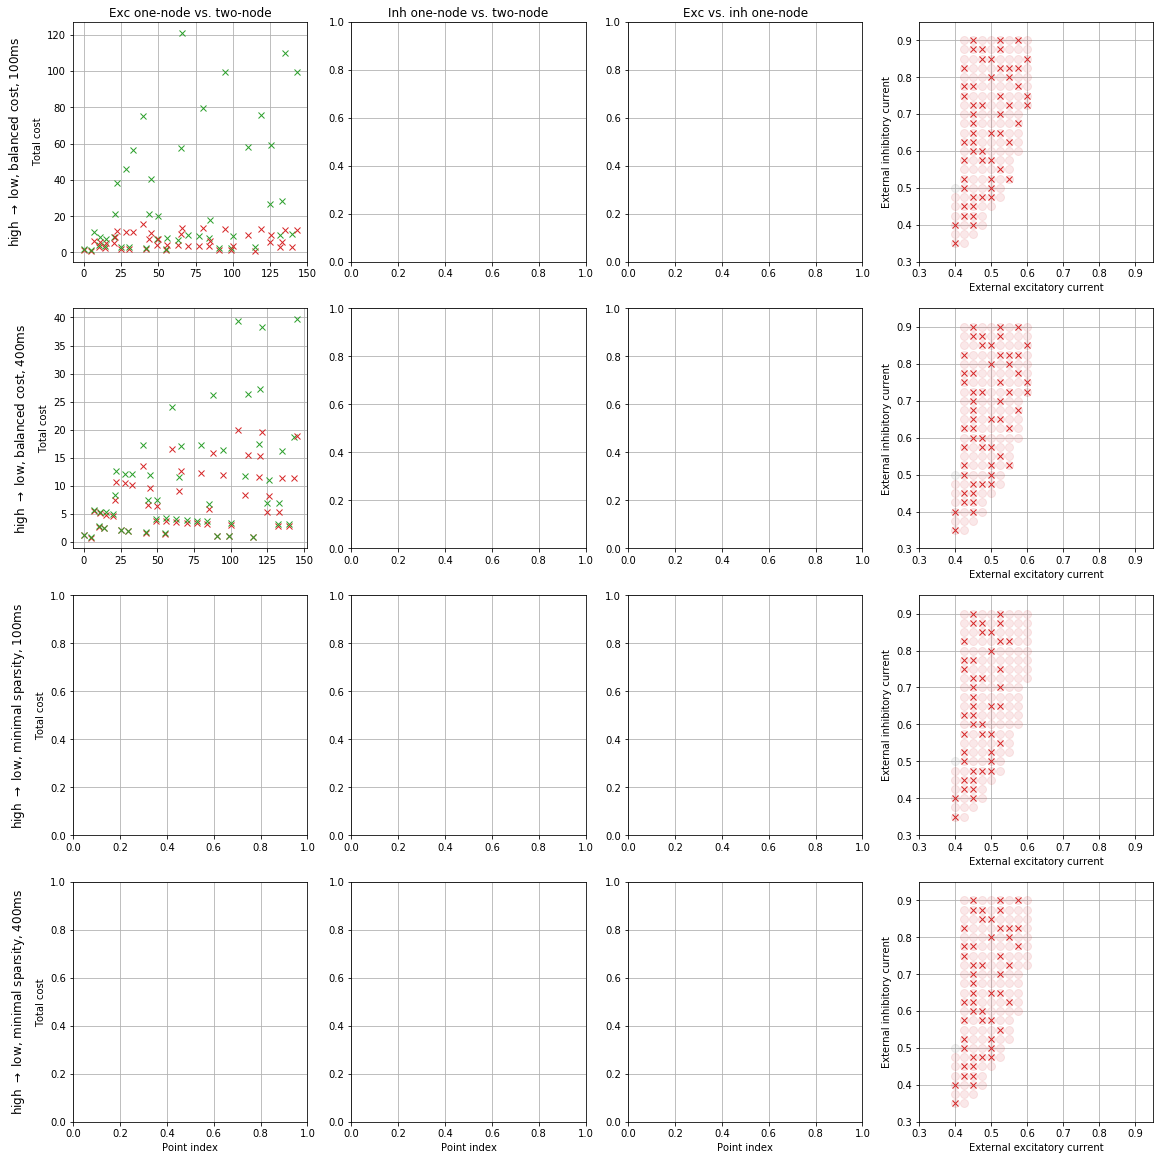

In [17]:
fig7, ax = plt.subplots(4, 4, constrained_layout=True, figsize = (16,16) )

rows = [r'high $\rightarrow$ low, balanced cost, 100ms', r'high $\rightarrow$ low, balanced cost, 400ms',
        r'high $\rightarrow$ low, minimal sparsity, 100ms', r'high $\rightarrow$ low, minimal sparsity, 400ms']

cases = [['10000', '10010'], ['10001', '10011'], ['10000max', '10010max'], ['10001max', '10011max']]

for k in range(len(cases)):
    print(rows[k])
    readcase(cases[k][0])
    cost_index = np.zeros(( len(ext_exc), 4 ))

    for i in range(len(ext_exc)):
        cost_index[i,0] = i
        for j in range(len(exc_)):
            if exc_[j] == i:
                cost_index[i,1] = cost1[j][0][0][0] + cost1[j][1][0][0] + cost1[j][2][0][0]
        for j in range(len(inh_)):
            if inh_[j] == i:
                cost_index[i,2] = cost2[j][0][0][1] + cost2[j][1][0][1] + cost2[j][2][0][1]
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][1][0][0] + cost3[j][2][0][0]
                                       + cost3[j][1][0][1] + cost3[j][2][0][1] )
            
    readcase(cases[k][1])

    for i in range(len(ext_exc)):
        for j in range(len(exc_)):
            if exc_[j] == i:
                if cost_index[i,1] == 0.:
                    cost_index[i,1] = cost1[j][0][0][0] + cost1[j][1][0][0] + cost1[j][2][0][0]
                else:
                    print("1 cost index already set, ", cost_index[i,1],
                          cost1[j][0][0][0] + cost1[j][1][0][0] + cost1[j][2][0][0])
        for j in range(len(inh_)):
            if inh_[j] == i:
                if cost_index[i,2] == 0.:
                    cost_index[i,2] = cost2[j][0][0][1] + cost2[j][1][0][1] + cost2[j][2][0][1]
                else:
                    print("2 cost index already set, ", cost_index[i,2],
                          cost2[j][0][0][0] + cost2[j][1][0][1] + cost2[j][2][0][1])
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                if cost_index[i,3] == 0.:
                    cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][1][0][0] + cost3[j][2][0][0]
                                       + cost3[j][1][0][1] + cost3[j][2][0][1] )
                else:
                    print("3 cost index already set, ", cost_index[i,3], cost3[j][0][0][0] + cost3[j][1][0][0]
                          + cost3[j][2][0][0] + cost3[j][1][0][1] + cost3[j][2][0][1] )

    for i in range(cost_index.shape[0]):
        if cost_index[i,1] != 0 and cost_index[i,3] != 0:
            ax[k,0].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,0].plot(i, cost_index[i,3], 'x', color=green)
            if cost_index[i,1] > cost_index[i,3]:
                print("exc only cost higher than two-node cost: ", i, cost_index[i,1] - cost_index[i,3])
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            else:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0 and cost_index[i,3] != 0:
            ax[k,1].plot(i, cost_index[i,2], 'x', color=inh_blue)
            ax[k,1].plot(i, cost_index[i,3], 'x', color=green)
            if cost_index[i,2] > cost_index[i,3]:
                print("inh only cost higher than two-node cost: ", i, cost_index[i,2] - cost_index[i,3])
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            else:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0 and cost_index[i,2] != 0:
            ax[k,2].plot(i, cost_index[i,1], 'x', color=exc_red)
            ax[k,2].plot(i, cost_index[i,2], 'x', color=inh_blue)
            if cost_index[i,1] < cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,1] > cost_index[i,2]:
                ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)


        dist_x = data.dist_left(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
        dist_y = data.dist_up(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)

        if (dist_x - dist_y) < - 1e-4 or i > 40:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=exc_red)
        elif (dist_x - dist_y) > 1e-4:
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=inh_blue)
        else:
            #print("apparently same distance: ", i, dist_x, dist_y)
            ax[k,3].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color='grey')

    ax[k,0].set_ylabel("Total cost")
    ax[k,3].set_xlim(0.3, 0.95)
    ax[k,3].set_ylim(0.3, 0.95)

#######################################################

cols = ['Exc one-node vs. two-node', 'Inh one-node vs. two-node', 'Exc vs. inh one-node']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)
        

ax[3,0].set_xlabel("Point index")
ax[3,1].set_xlabel("Point index")
ax[3,2].set_xlabel("Point index")

for i in range(4):        
    ax[i,3].set_xlabel("External excitatory current")
    ax[i,3].set_ylabel("External inhibitory current")

plt.savefig(os.path.join(os.getcwd(), 'regions_lh'))

#print(exc_, inh_, both_c_, no_c_)